# CNN Analysis Notebook

## 0. Setup & Load Results

In [15]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "src" / "notebook").exists():
            return candidate
        for child in candidate.iterdir() if candidate.is_dir() else []:
            if child.is_dir() and (child / "src" / "notebook").exists():
                return child
    return current


REPO_ROOT = find_repo_root()

candidate_output_roots = [
    Path(os.getenv("CNN_OUTPUT_DIR", "")) if os.getenv("CNN_OUTPUT_DIR") else None,
    REPO_ROOT / "src" / "outputs" / "cnn",
    REPO_ROOT / "outputs" / "cnn",
    Path("/kaggle/working/outputs/cnn"),
]
CNN_ROOT = next((p for p in candidate_output_roots if p and (p / "summary.csv").exists()), None)
if CNN_ROOT is None:
    raise FileNotFoundError("Tidak menemukan summary.csv. Set CNN_OUTPUT_DIR ke folder outputs/cnn hasil training.")

ANALYSIS_DIR = CNN_ROOT / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(CNN_ROOT / "summary.csv")
summary = summary.sort_values("macro_f1", ascending=False).reset_index(drop=True)

shared_vs_non_shared_path = CNN_ROOT / "shared_vs_non_shared.csv"
shared_vs_non_shared = pd.read_csv(shared_vs_non_shared_path) if shared_vs_non_shared_path.exists() else pd.DataFrame()

scratch_path = CNN_ROOT / "scratch_compare.json"
scratch_compare = json.loads(scratch_path.read_text(encoding="utf-8")) if scratch_path.exists() else {}

notebook_summary_path = CNN_ROOT / "notebook_summary.json"
notebook_summary = json.loads(notebook_summary_path.read_text(encoding="utf-8")) if notebook_summary_path.exists() else {}

print("Repo root:", REPO_ROOT)
print("CNN output root:", CNN_ROOT)
print("Analysis output:", ANALYSIS_DIR)
summary.head()

Repo root: C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa
CNN output root: C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa\src\outputs\cnn
Analysis output: C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa\src\outputs\cnn\analysis


,experiment,conv_depth,filters_base,kernel_size,pooling,non_shared,macro_f1,test_accuracy,param_count
0,shared_d2_f32_k3_max,2,32,3,max,False,0.789103,0.788333,822662
1,shared_d2_f32_k3_avg,2,32,3,avg,False,0.771382,0.769000,822662
2,shared_d2_f16_k3_max,2,16,3,max,False,0.764432,0.764000,406950
3,shared_d2_f16_k3_avg,2,16,3,avg,False,0.761966,0.761667,406950
4,shared_d2_f16_k5_avg,2,16,5,avg,False,0.758410,0.756333,360614


In [16]:
def save_current_fig(name: str):
    path = ANALYSIS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("saved:", path)
    return path


def read_json(path: Path, default=None):
    if not path.exists():
        return default
    return json.loads(path.read_text(encoding="utf-8"))


def history_for_experiment(experiment: str):
    return read_json(CNN_ROOT / experiment / "history.json", {})


def group_stats(column: str):
    return (
        summary.groupby(column)
        .agg(
            mean_macro_f1=("macro_f1", "mean"),
            best_macro_f1=("macro_f1", "max"),
            mean_test_accuracy=("test_accuracy", "mean"),
            mean_param_count=("param_count", "mean"),
            n_experiments=("experiment", "count"),
        )
        .reset_index()
    )


def plot_group(column: str, xlabel: str, filename: str):
    stats = group_stats(column)
    labels = stats[column].astype(str)
    x = np.arange(len(stats))
    width = 0.36

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - width / 2, stats["mean_macro_f1"], width, label="Mean macro F1")
    ax.bar(x + width / 2, stats["best_macro_f1"], width, label="Best macro F1")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Macro F1-score")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, max(1.0, float(stats[["mean_macro_f1", "best_macro_f1"]].max().max()) + 0.08))
    ax.legend()
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=8)
    save_current_fig(filename)
    plt.show()
    return stats

## 1. Ringkasan 16 Eksperimen Shared CNN

In [17]:
summary

,experiment,conv_depth,filters_base,kernel_size,pooling,non_shared,macro_f1,test_accuracy,param_count
0,shared_d2_f32_k3_max,2,32,3,max,False,0.789103,0.788333,822662
1,shared_d2_f32_k3_avg,2,32,3,avg,False,0.771382,0.769000,822662
2,shared_d2_f16_k3_max,2,16,3,max,False,0.764432,0.764000,406950
3,shared_d2_f16_k3_avg,2,16,3,avg,False,0.761966,0.761667,406950
4,shared_d2_f16_k5_avg,2,16,5,avg,False,0.758410,0.756333,360614
5,shared_d2_f32_k5_max,2,32,5,max,False,0.750277,0.751000,746374
6,shared_d2_f32_k5_avg,2,32,5,avg,False,0.744973,0.744333,746374
7,shared_d2_f16_k5_max,2,16,5,max,False,0.742485,0.741000,360614
8,shared_d1_f32_k5_max,1,32,5,max,False,0.726627,0.726000,1846086
9,shared_d1_f32_k3_avg,1,32,3,avg,False,0.723456,0.723333,1969478


saved: C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa\src\outputs\cnn\analysis\01_all_experiments_macro_f1.png


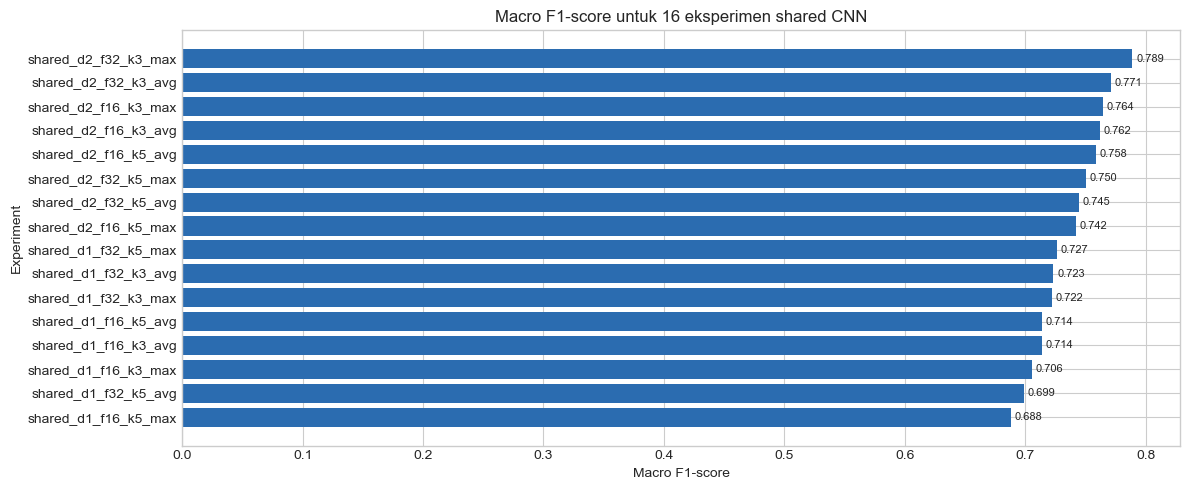

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = summary.sort_values("macro_f1", ascending=True)
ax.barh(plot_df["experiment"], plot_df["macro_f1"], color="#2b6cb0")
ax.set_xlabel("Macro F1-score")
ax.set_ylabel("Experiment")
ax.set_title("Macro F1-score untuk 16 eksperimen shared CNN")
for i, value in enumerate(plot_df["macro_f1"]):
    ax.text(value + 0.003, i, f"{value:.3f}", va="center", fontsize=8)
save_current_fig("01_all_experiments_macro_f1.png")
plt.show()

## 2. Perbandingan Shared vs Non-Shared Parameter

In [19]:
shared_vs_non_shared

,model_type,experiment,macro_f1,test_accuracy,param_count
0,shared,shared_d2_f32_k3_max,0.789103,0.788333,822662
1,non_shared,non_shared_d2_f32_k3_max,0.644364,0.656333,19802630


saved: C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa\src\outputs\cnn\analysis\02_shared_vs_non_shared_metrics.png


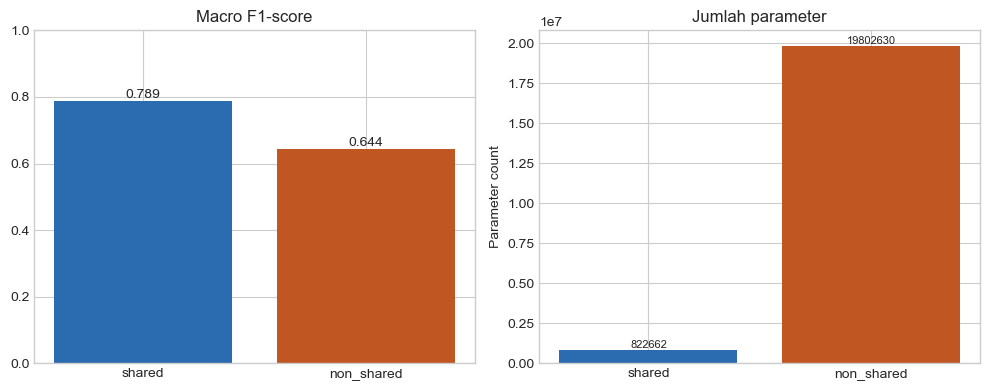

In [20]:
if not shared_vs_non_shared.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    labels = shared_vs_non_shared["model_type"]

    axes[0].bar(labels, shared_vs_non_shared["macro_f1"], color=["#2b6cb0", "#c05621"])
    axes[0].set_title("Macro F1-score")
    axes[0].set_ylim(0, max(1.0, shared_vs_non_shared["macro_f1"].max() + 0.08))
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt="%.3f")

    axes[1].bar(labels, shared_vs_non_shared["param_count"], color=["#2b6cb0", "#c05621"])
    axes[1].set_title("Jumlah parameter")
    axes[1].set_ylabel("Parameter count")
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt="%.0f", fontsize=8)

    save_current_fig("02_shared_vs_non_shared_metrics.png")
    plt.show()
else:
    print("shared_vs_non_shared.csv tidak ditemukan atau kosong")

saved: C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa\src\outputs\cnn\analysis\03_shared_vs_non_shared_loss.png


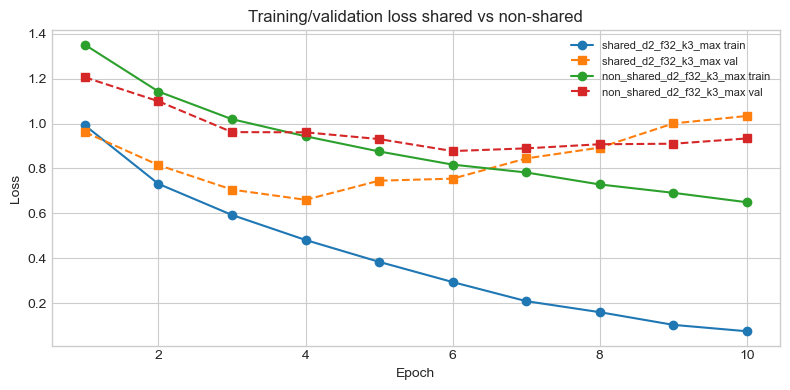

In [21]:
if not shared_vs_non_shared.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    for exp in shared_vs_non_shared["experiment"]:
        hist = history_for_experiment(exp)
        if not hist:
            continue
        epochs = np.arange(1, len(hist.get("loss", [])) + 1)
        ax.plot(epochs, hist.get("loss", []), marker="o", label=f"{exp} train")
        if "val_loss" in hist:
            ax.plot(epochs, hist["val_loss"], marker="s", linestyle="--", label=f"{exp} val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training/validation loss shared vs non-shared")
    ax.legend(fontsize=8)
    save_current_fig("03_shared_vs_non_shared_loss.png")
    plt.show()

## 3. Pengaruh Jumlah Layer Konvolusi

saved: C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa\src\outputs\cnn\analysis\04_conv_depth_effect.png


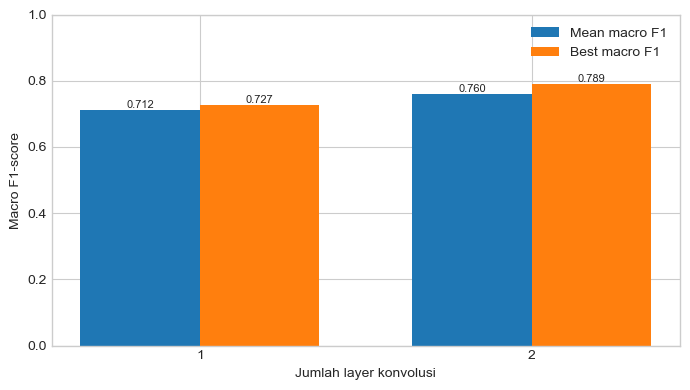

,conv_depth,mean_macro_f1,best_macro_f1,mean_test_accuracy,mean_param_count,n_experiments
0,1,0.711644,0.726627,0.711333,1430950.0,8
1,2,0.760379,0.789103,0.759458,584150.0,8


In [22]:
depth_stats = plot_group("conv_depth", "Jumlah layer konvolusi", "04_conv_depth_effect.png")
depth_stats

## 4. Pengaruh Banyak Filter per Layer Konvolusi

saved: C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa\src\outputs\cnn\analysis\05_filters_effect.png


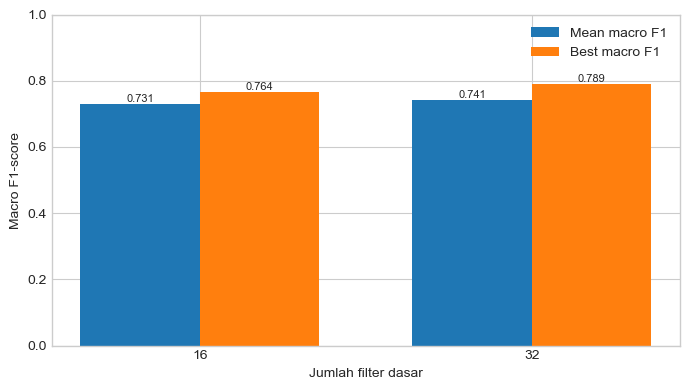

,filters_base,mean_macro_f1,best_macro_f1,mean_test_accuracy,mean_param_count,n_experiments
0,16,0.731160,0.764432,0.730333,668950.0,8
1,32,0.740863,0.789103,0.740458,1346150.0,8


In [23]:
filter_stats = plot_group("filters_base", "Jumlah filter dasar", "05_filters_effect.png")
filter_stats

## 5. Pengaruh Ukuran Filter per Layer Konvolusi

saved: C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa\src\outputs\cnn\analysis\06_kernel_size_effect.png


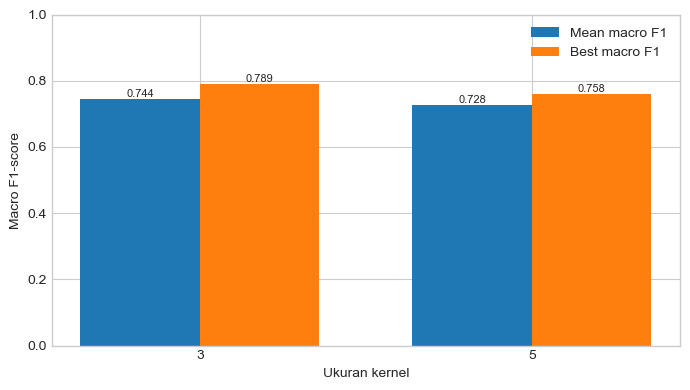

,kernel_size,mean_macro_f1,best_macro_f1,mean_test_accuracy,mean_param_count,n_experiments
0,3,0.744006,0.789103,0.743458,1046014.0,8
1,5,0.728017,0.758410,0.727333,969086.0,8


In [24]:
kernel_stats = plot_group("kernel_size", "Ukuran kernel", "06_kernel_size_effect.png")
kernel_stats

## 6. Pengaruh Jenis Pooling Layer

saved: C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa\src\outputs\cnn\analysis\07_pooling_effect.png


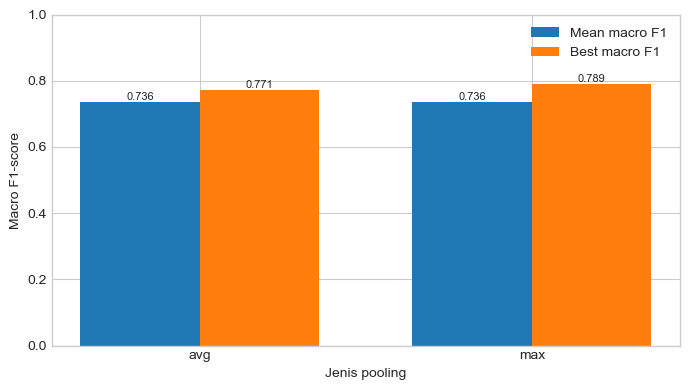

,pooling,mean_macro_f1,best_macro_f1,mean_test_accuracy,mean_param_count,n_experiments
0,avg,0.735878,0.771382,0.734792,1007550.0,8
1,max,0.736145,0.789103,0.736000,1007550.0,8


In [25]:
pooling_stats = plot_group("pooling", "Jenis pooling", "07_pooling_effect.png")
pooling_stats

## 7. Perbandingan Keras vs From Scratch

In [26]:
scratch_table = pd.DataFrame([scratch_compare]) if scratch_compare else pd.DataFrame()
scratch_table

,samples,keras_macro_f1,scratch_macro_f1,max_abs_probability_diff,prediction_match_rate
0,30,0.173585,0.173585,5.364418e-07,1.0


saved: C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa\src\outputs\cnn\analysis\08_keras_vs_scratch.png


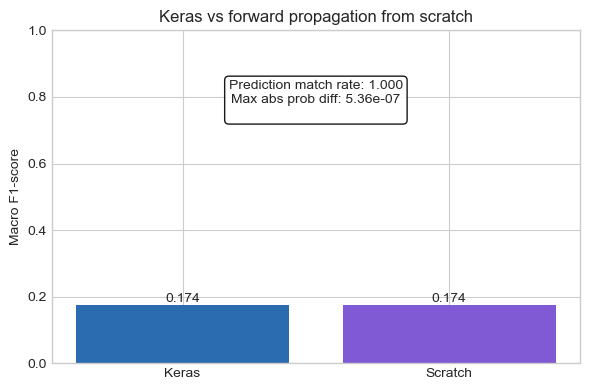

In [31]:
if scratch_compare:
    labels = ["Keras", "Scratch"]
    values = [scratch_compare.get("keras_macro_f1"), scratch_compare.get("scratch_macro_f1")]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(labels, values, color=["#2b6cb0", "#805ad5"])
    ax.set_ylabel("Macro F1-score")
    ax.set_title("Keras vs forward propagation from scratch")
    ax.set_ylim(0, max(1.0, max(values) + 0.08))
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f")
    text = (
        f"Prediction match rate: {scratch_compare.get('prediction_match_rate', 0):.3f}\n"
        f"Max abs prob diff: {scratch_compare.get('max_abs_probability_diff', 0):.2e}\n"
    )
    ax.text(0.5, 0.85, text, transform=ax.transAxes, ha="center", va="top", bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9})
    save_current_fig("08_keras_vs_scratch.png")
    plt.show()

## 8. Export

In [28]:
analysis_summary = {
    "best_experiment": summary.iloc[0].to_dict(),
    "conv_depth": depth_stats.to_dict(orient="records"),
    "filters_base": filter_stats.to_dict(orient="records"),
    "kernel_size": kernel_stats.to_dict(orient="records"),
    "pooling": pooling_stats.to_dict(orient="records"),
    "shared_vs_non_shared": shared_vs_non_shared.to_dict(orient="records"),
    "scratch_compare": scratch_compare,
}

with (ANALYSIS_DIR / "analysis_summary.json").open("w", encoding="utf-8") as f:
    json.dump(analysis_summary, f, indent=2)

summary.to_csv(ANALYSIS_DIR / "summary_sorted.csv", index=False)
depth_stats.to_csv(ANALYSIS_DIR / "conv_depth_stats.csv", index=False)
filter_stats.to_csv(ANALYSIS_DIR / "filters_base_stats.csv", index=False)
kernel_stats.to_csv(ANALYSIS_DIR / "kernel_size_stats.csv", index=False)
pooling_stats.to_csv(ANALYSIS_DIR / "pooling_stats.csv", index=False)

print("Exported analysis files to", ANALYSIS_DIR)
sorted(p.name for p in ANALYSIS_DIR.iterdir())

Exported analysis files to C:\COOLYEAH\SMT_6\ML\Tubes2\SpreiElsa\src\outputs\cnn\analysis


['01_all_experiments_macro_f1.png',
 '02_conv_depth_effect.png',
 '02_shared_vs_non_shared_metrics.png',
 '03_filters_effect.png',
 '03_shared_vs_non_shared_loss.png',
 '04_conv_depth_effect.png',
 '04_kernel_size_effect.png',
 '05_filters_effect.png',
 '05_pooling_effect.png',
 '06_kernel_size_effect.png',
 '06_shared_vs_non_shared_metrics.png',
 '07_pooling_effect.png',
 '07_shared_vs_non_shared_loss.png',
 '08_keras_vs_scratch.png',
 'analysis_summary.json',
 'conv_depth_stats.csv',
 'filters_base_stats.csv',
 'kernel_size_stats.csv',
 'pooling_stats.csv',
 'summary_sorted.csv']